# Monte Carlo Option Pricing

This notebook develops a Monte Carlo framework for pricing financial options.

We begin by simulating the underlying asset using Geometric Brownian Motion (GBM), and then use the simulated paths to estimate option prices.

The progression of the project is:

1. Random number generation
2. GBM path simulation
3. Visualization of simulated paths
4. European option pricing
5. Validation against the Black-Scholes formula
6. Monte Carlo convergence and standard error
7. Asian options
8. Lookback options
9. Barrier options
10. Variance reduction techniques

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Model and Option Parameters

We assume that the underlying asset follows a Geometric Brownian Motion (GBM) under the risk-neutral measure:

$$
dS_t = rS_t\,dt + \sigma S_t\,dW_t^Q
$$

where:

- $S_t$ = stock price at time $t$
- $r$ = risk-free interest rate
- $\sigma$ = volatility of the stock
- $W_t^Q$ = Brownian motion under the risk-neutral measure $Q$

For option pricing, the drift is the risk-free rate $r$ rather than the stock's real-world expected return $\mu$.

The time-0 value of an option with payoff $H$ is

$$
V(0,T) = e^{-rT} E_Q[H].
$$

In [2]:
# Stock and option parameters

S0 = 100.0      # Initial stock price
K = 100.0       # Strike price
r = 0.05        # Risk-free interest rate
sigma = 0.20    # Volatility
T = 1.0         # Time to maturity (years)

# Simulation parameters

n_steps = 252   # Number of time steps
n_paths = 100   # Number of simulated paths

## 2. Random Numbers and Time Discretization

Monte Carlo simulation requires random samples from probability distributions.

For the GBM model, we need independent standard normal random variables:

$$
Z_i \sim N(0,1).
$$

We divide the time interval $[0,T]$ into $N$ equally spaced intervals:

$$
\Delta t = \frac{T}{N}.
$$

The corresponding Brownian-motion increment is

$$
\Delta W_i = \sqrt{\Delta t}\,Z_i.
$$

Since

$$
Z_i \sim N(0,1),
$$

we have

$$
\Delta W_i \sim N(0,\Delta t).
$$

In [3]:
# Generate standard normal random variables

Z = np.random.normal(0, 1, 10000)

print("Mean:", np.mean(Z))
print("Standard deviation:", np.std(Z))

Mean: 0.006277903502943098
Standard deviation: 1.0141675137765211


### Distribution of Standard Normal Samples

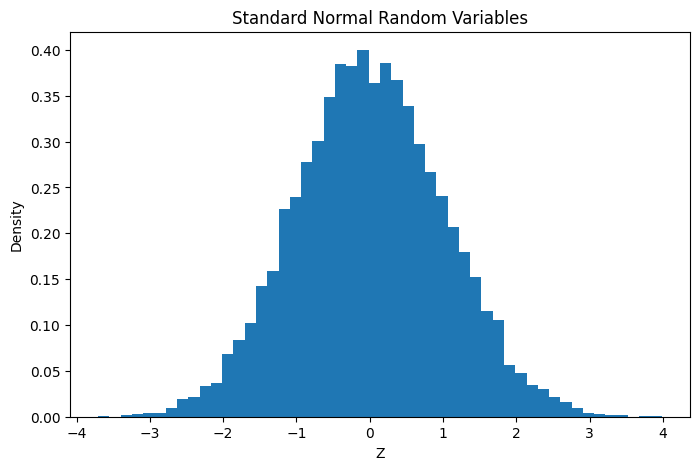

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(Z, bins=50, density=True)

plt.xlabel("Z")
plt.ylabel("Density")
plt.title("Standard Normal Random Variables")

plt.show()

In [5]:
dt = T / n_steps

print("dt =", dt)
print("sqrt(dt) =", np.sqrt(dt))

dt = 0.003968253968253968
sqrt(dt) = 0.06299407883487121


In [6]:
dW = np.sqrt(dt) * Z

print("Mean of dW:", np.mean(dW))
print("Standard deviation of dW:", np.std(dW))
print("Theoretical standard deviation:", np.sqrt(dt))

Mean of dW: 0.00039547074818211157
Standard deviation of dW: 0.0638865483146035
Theoretical standard deviation: 0.06299407883487121


## 3. Simulating Geometric Brownian Motion

We model the underlying stock price under the risk-neutral measure using Geometric Brownian Motion:

$$
dS_t = rS_t\,dt + \sigma S_t\,dW_t^Q.
$$

For GBM, the exact solution over a time interval $\Delta t$ is

$$
S_{t+\Delta t}
=
S_t
\exp\left[
\left(r-\frac{1}{2}\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right],
$$

where

$$
Z\sim N(0,1).
$$

Therefore, starting from $S_0$, we can repeatedly apply this transition to construct a complete simulated stock-price path.

In [7]:
# Create an array to store all simulated paths

paths = np.zeros((n_paths, n_steps + 1))

# Every path starts at S0
paths[:, 0] = S0

print("Shape of paths:", paths.shape)

Shape of paths: (100, 253)


In [8]:
for i in range(n_steps):

    # Generate one random shock for every path
    Z = np.random.normal(0, 1, n_paths)

    # Apply the exact GBM transition
    paths[:, i + 1] = paths[:, i] * np.exp(
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z
    )

In [9]:
print(paths[0])

[100.         101.29535486 101.63316826 102.27775492 103.22184222
 102.9054397   98.70633222 102.36945758 102.59813059 100.96138939
 101.76225995 101.31055554 101.75119408  99.15695251 100.88298849
 101.38484158 102.72846066 101.7952942  100.15598061 101.64057494
 100.71169097 101.22842529 100.47937988 101.04263571 101.86047923
 103.57897907 106.11768312 107.19445813 108.03811002 107.3701288
 109.0255844  108.48828856 105.00063402 106.21335771 107.6075771
 109.52695977 110.58707392 110.46772832 110.04095089 108.52758793
 109.9214421  111.97465116 113.12966767 112.9043372  113.83528435
 113.02157492 111.8020469  113.46881737 111.80416381 113.27798014
 115.4236885  114.14641111 113.53642403 114.1586297  111.51295903
 111.63667755 112.47586586 112.25365102 112.60526426 113.73924932
 115.70535419 114.58687346 116.13027596 117.71774891 117.75670284
 117.65063607 116.37156437 115.64536078 113.94632961 114.72436213
 112.19704147 114.60696588 114.0202711  113.85319828 114.44524376
 114.3416915

### Simulated Stock Price Paths

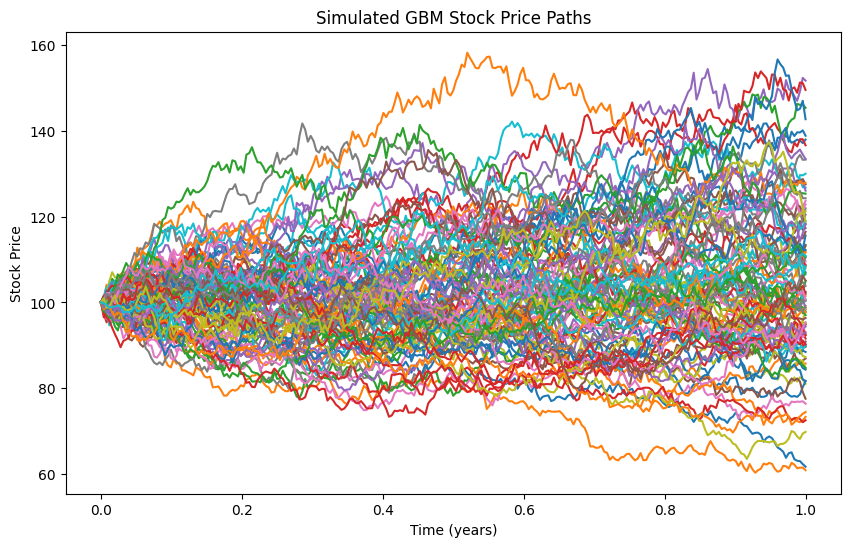

In [10]:
time = np.linspace(0, T, n_steps + 1)

plt.figure(figsize=(10, 6))

for i in range(n_paths):
    plt.plot(time, paths[i])

plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.title("Simulated GBM Stock Price Paths")

plt.show()